In [4]:
import numpy as np
import re
import random
import string

#chargement du fichier
TEXT_PATH = "C:/Users/HP/Downloads/Harry-potter-sorcerers-stone.txt"   
with open(TEXT_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

print(f"Longueur brute du texte : {len(raw_text)} caractères")
print(raw_text[:300])


Longueur brute du texte : 436649 caractères
HP 1 - Harry Potter and the
Sorcerer's Stone
Harry Potter and the Sorcerer's Stone

Harry Potter
&
The Sorcerer’s Stone

by J.K. Rowling

HP 1 - Harry Potter and the
Sorcerer's Stone

CHAPTER ONE
THE BOY WHO LIVED
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say
that they w


In [5]:
#Suppression des caractères non-ASCII et normalisation (minuscules) 
def clean_text(text):
    # Ne garder que les caractères ASCII imprimables
    text = text.encode("ascii", errors="ignore").decode("ascii")
    # Mise en minuscules pour réduire la taille du vocabulaire
    text = text.lower()
    # Normalisation des espaces multiples
    text = re.sub(r"\s+", " ", text)
    return text

text = clean_text(raw_text)
print(f"Longueur après nettoyage : {len(text)} caractères")
print(text[:300])

Longueur après nettoyage : 426222 caractères
 hp 1 - harry potter and the sorcerer's stone harry potter and the sorcerer's stone harry potter & the sorcerers stone by j.k. rowling hp 1 - harry potter and the sorcerer's stone chapter one the boy who lived m r. and mrs. dursley, of number four, privet drive, were proud to say that they were perf


In [6]:
#
chars = sorted(list(set(text)))
V = len(chars)

char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}

print(f"Taille du vocabulaire V = {V}")
print(f"Caractères : {chars}")


Taille du vocabulaire V = 49
Caractères : [' ', '!', '&', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [5]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.3

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
 import sys
print(sys.executable)
 

C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe


In [7]:
!{sys.executable} -m pip uninstall -y protobuf
!{sys.executable} -m pip install protobuf==3.19.6

Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sdk 0.120.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 3.19.6 which is incompatible.
mage-ai 0.9.65 requires cryptography==41.0.6, but you have cryptography 48.0.1 which is incompatible.
mage-ai 0.9.65 requires itsdangerous~=1.1.0, but you have itsdangerous 2.2.0 which is incompatible.
mage-ai 0.9.65 requires protobuf~=4.21.12, but you have protobuf 3.19.6 which is incompatible.
mage-ai 0.9.65 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
mage-ai 0.9.65 requires typing-extensions==4.5.0, but you have typing-extensions 4.15.0 which is incompatible.
mlflow-skinny 3.14.0 requires pydantic<3,>=2.0.0, but you have pydantic 1.10.26 which is incompatib


   ---------------------------------------- 895.7/895.7 kB 5.8 MB/s  0:00:00


In [1]:
import google.protobuf

print("Protobuf :", google.protobuf.__version__)

Protobuf : 3.19.6


In [2]:
import tensorflow as tf

print("TensorFlow :", tf.__version__)

TensorFlow : 2.10.1


In [7]:
from tensorflow.keras.utils import to_categorical

L = 100  # longueur de séquence
step = 3  # pas de glissement (pour limiter le nombre de séquences ; step=1 = tous les décalages)

sequences = []
next_chars = []

for i in range(0, len(text) - L, step):
    sequences.append(text[i:i + L])
    next_chars.append(text[i + L])

n_sequences = len(sequences)
print(f"Nombre de séquences : {n_sequences}")

# Encodage entier des séquences (avant normalisation)
X_int = np.zeros((n_sequences, L), dtype=np.int32)
y_int = np.zeros((n_sequences,), dtype=np.int32)

for i, seq in enumerate(sequences):
    for t, ch in enumerate(seq):
        X_int[i, t] = char2idx[ch]
    y_int[i] = char2idx[next_chars[i]]

y = to_categorical(y_int, num_classes=V)
print("X_int shape :", X_int.shape)
print("y shape :", y.shape)


Nombre de séquences : 142041
X_int shape : (142041, 100)
y shape : (142041, 49)


In [8]:
#Normalisation de X

X = X_int.astype("float32") / float(V)
X = X.reshape((n_sequences, L, 1))
print("X shape :", X.shape)


X shape : (142041, 100, 1)


In [9]:
#Construction du modèle Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(L, 1)),
    LSTM(128, return_sequences=False),
    Dense(V, activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128)               66560     
                                                                 
 dense (Dense)               (None, 49)                6321      
                                                                 
Total params: 72,881
Trainable params: 72,881
Non-trainable params: 0
_________________________________________________________________


In [10]:
#compilation et entrainement 
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model.fit(
    X, y,
    batch_size=128,
    epochs=30,
    verbose=1
)


Epoch 1/30
1110/1110 [==============================] - 238s 215ms/step - loss: 2.7604 - accuracy: 0.2127
Epoch 3/30
1110/1110 [==============================] - 243s 219ms/step - loss: 2.7205 - accuracy: 0.2230
Epoch 4/30
1110/1110 [==============================] - 245s 220ms/step - loss: 2.6913 - accuracy: 0.2314
Epoch 5/30
1110/1110 [==============================] - 256s 230ms/step - loss: 2.6620 - accuracy: 0.2390
Epoch 6/30
1110/1110 [==============================] - 251s 226ms/step - loss: 2.6361 - accuracy: 0.2471
Epoch 7/30
1110/1110 [==============================] - 281s 253ms/step - loss: 2.6116 - accuracy: 0.2533
Epoch 8/30
1110/1110 [==============================] - 255s 230ms/step - loss: 2.5914 - accuracy: 0.2581
Epoch 9/30
1110/1110 [==============================] - 252s 227ms/step - loss: 2.5739 - accuracy: 0.2616
Epoch 10/30
1110/1110 [==============================] - 249s 225ms/step - loss: 2.5569 - accuracy: 0.2651
Epoch 11/30
1110/1110 [======================

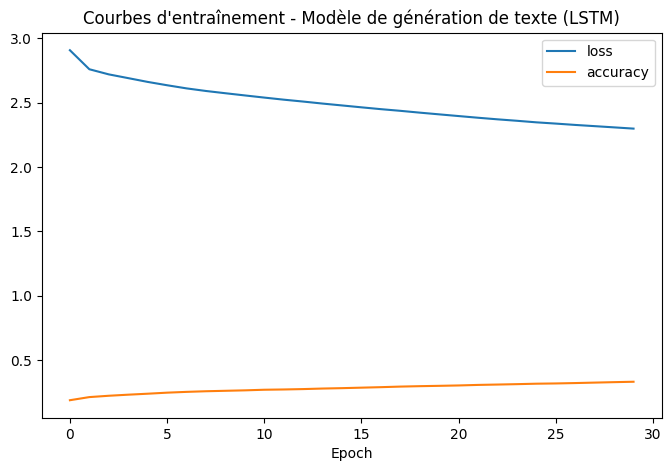

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.xlabel("Epoch")
plt.title("Courbes d'entraînement - Modèle de génération de texte (LSTM)")
plt.legend()
plt.show()

In [12]:
def sample_with_temperature(preds, temperature=0.5):
    """Ré-échantillonne une distribution softmax avec une température T.
    T < 1 -> distribution plus 'piquée' (plus déterministe)
    T > 1 -> distribution plus 'plate' (plus aléatoire)
    """
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def generate_text(seed_text, length=200, temperature=0.5):
    seed_text = clean_text(seed_text)
    # On ne garde que les caractères connus du vocabulaire
    seed_text = "".join([c for c in seed_text if c in char2idx])

    # Si la graine est plus courte que L, on la complète à gauche avec des espaces
    if len(seed_text) < L:
        seed_text = " " * (L - len(seed_text)) + seed_text
    else:
        seed_text = seed_text[-L:]

    generated = seed_text

    for _ in range(length):
        # Encodage de la fenêtre courante
        x_pred = np.zeros((1, L, 1), dtype="float32")
        window = generated[-L:]
        for t, ch in enumerate(window):
            x_pred[0, t, 0] = char2idx[ch] / float(V)

        preds = model.predict(x_pred, verbose=0)[0]
        next_index = sample_with_temperature(preds, temperature)
        next_char = idx2char[next_index]

        generated += next_char

    return generated


In [13]:
seeds = ["Harry", "The magic", "Professor"]

generated_texts = {}
for seed in seeds:
    gen = generate_text(seed, length=200, temperature=0.5)
    generated_texts[seed] = gen
    print(f"--- Graine : '{seed}' ---")
    print(gen)
    print()

--- Graine : 'Harry' ---
                                                                                               harry aaa halry pooee to tie birts bdoiti the mooe oo toe tiale oi the tacd ouir oooe bnd shete seiel toaerent sfa bny oh the crroee oars tfe cir ff oalted thee to goo ooen the foost soane tes aod phlttee 

--- Graine : 'The magic' ---
                                                                                           the magic io the rertleg th toe barltn ir the fer testoe the soaer aalkt tt br a cuas war oaring ald tee sheee fooege the rart bean nolt hos oa tacdh to the frosnele hn anl. tald rartoel toopg tae toe pia dore

--- Graine : 'Professor' ---
                                                                                           professor magtiog hnp the aar ta savcr to the harse fn bio. bnd then would hroe bua phver teit dare the ooahr, he was a luot iertens anr the shrt toeete to the fertt hr tha hltferse aid ta dane toene fari thee



### Commentaire sur la cohérence orthographique et syntaxique
### Commentaire sur la cohérence orthographique et syntaxique

Les trois textes générés à partir des graines **« Harry »**, **« The magic »** et **« Professor »** montrent que le modèle a appris certaines régularités du texte anglais. On retrouve notamment des mots fréquents comme *the*, *to*, *and*, *she*, *was* ou *would*, ainsi que des structures locales ressemblant à des phrases anglaises.

Cependant, la **cohérence orthographique reste limitée**. Le modèle produit plusieurs mots mal orthographiés ou inexistants, comme *« halry »*, *« pooee »*, *« rertleg »* ou *« barltn »*. Cela s'explique par le fait qu'il génère le texte **caractère par caractère** : une erreur sur un caractère peut entraîner la formation d'un mot incorrect.

La **cohérence syntaxique est meilleure localement**, car le modèle reproduit certaines structures fréquentes telles que *« he was... »*, *« and then... »* ou *« the... »*. Néanmoins, les phrases restent globalement difficiles à comprendre et la cohérence sémantique à long terme est faible. Le modèle utilise une fenêtre de contexte de **L = 100 caractères**, ce qui lui permet d'apprendre des relations locales, mais ne lui donne pas une compréhension réelle de la grammaire ou du sens du texte.

Le résultat obtenu après 30 époques confirme que le modèle est en train d'apprendre : l'accuracy est passée de **21,27 % à 33,20 %**, tandis que la loss a diminué de **2,7604 à 2,2990**. La progression régulière de ces deux indicateurs montre que le modèle apprend effectivement les régularités du corpus, même si la génération reste encore imparfaite.


 

### A.9 — Pourquoi le texte généré contient-il des fautes et des mots inventés ?

Les fautes et les mots inventés proviennent principalement du fait que le modèle apprend la langue **au niveau des caractères**. Il estime la probabilité du caractère suivant à partir des caractères précédents, sans posséder de dictionnaire, de règles grammaticales ou de compréhension sémantique.

Plusieurs facteurs expliquent ces erreurs :

1. **Le sampling stochastique** : la température utilisée lors de la génération introduit une part d'aléatoire. Elle permet de produire des textes plus variés, mais peut également conduire à choisir des caractères moins probables et donc à créer des mots inexistants.

2. **La capacité limitée du modèle** : notre réseau possède une seule couche LSTM de **128 unités** et environ **72 881 paramètres**. Cette capacité est suffisante pour apprendre certaines régularités locales, mais limitée pour mémoriser un vocabulaire important et des structures syntaxiques complexes.

3. **La génération caractère par caractère** : le modèle ne choisit pas directement un mot. Il choisit successivement chaque caractère. Une petite erreur peut donc transformer progressivement un mot correct en un mot inventé.

4. **La quantité de données** : le modèle est entraîné sur un corpus limité. Il ne peut donc pas observer suffisamment de variations lexicales et grammaticales pour reproduire parfaitement la langue anglaise.

### Trois améliorations possibles

**1. Amélioration architecturale : augmenter la capacité du réseau**

On peut utiliser davantage d'unités LSTM, par exemple **256 ou 512**, ou empiler plusieurs couches LSTM. On peut également utiliser des mécanismes d'attention ou un Transformer afin de mieux capturer les dépendances à longue distance.

**2. Amélioration data-centric : changer le niveau de génération**

Au lieu de générer caractère par caractère, on peut utiliser une représentation **au niveau des mots ou des sous-mots (BPE)**. Le modèle apprendrait alors directement des unités linguistiques plus significatives, ce qui réduirait fortement la production de mots mal orthographiés.

**3. Amélioration data-centric : augmenter et améliorer le corpus**

On peut entraîner le modèle sur un corpus plus important et plus diversifié, contenant plusieurs livres ou textes anglais. Un nettoyage préalable des données et une quantité plus importante d'exemples permettraient au modèle de mieux apprendre les régularités orthographiques et syntaxiques. On pourrait également utiliser une validation et `EarlyStopping` pour déterminer automatiquement la durée optimale de l'entraînement.

### Conclusion

Les résultats obtenus montrent que le modèle **apprend effectivement les régularités du corpus**, comme le confirme l'amélioration de l'accuracy de **21,27 % à 33,20 %** et la diminution continue de la loss. Il est capable de produire des séquences ressemblant à de l'anglais et de reproduire certains mots et motifs syntaxiques fréquents. Toutefois, la génération contient encore de nombreuses fautes et des mots inventés, car le modèle fonctionne au niveau caractère et possède une capacité limitée. L'augmentation de la capacité du réseau, l'utilisation d'une représentation par mots ou sous-mots et l'utilisation d'un corpus plus important permettraient d'obtenir des textes beaucoup plus cohérents.


#Chargement et parsing du corpus NER

In [15]:
import pandas as pd

NER_PATH ="C:/Users/HP/Downloads/ner_dataset.csv"     
df = pd.read_csv(NER_PATH, encoding="latin1")
df = df.ffill()  
print(df.shape)
df.head()


(1048575, 4)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O


In [16]:
class SentenceGetter:
    """Regroupe le DataFrame en une liste de phrases,
    chaque phrase étant une liste de tuples (token, pos, ner_tag)."""

    def __init__(self, data):
        self.sentences = []
        grouped = data.groupby("Sentence #").apply(
            lambda s: [(w, p, t) for w, p, t in zip(s["Word"], s["POS"], s["Tag"])]
        )
        self.sentences = list(grouped)

getter = SentenceGetter(df)
sentences = getter.sentences

print(f"Nombre de phrases : {len(sentences)}")
print(sentences[0])

Nombre de phrases : 47959
[('Thousands', 'NNS', 'O'), ('of', 'IN', 'O'), ('demonstrators', 'NNS', 'O'), ('have', 'VBP', 'O'), ('marched', 'VBN', 'O'), ('through', 'IN', 'O'), ('London', 'NNP', 'B-geo'), ('to', 'TO', 'O'), ('protest', 'VB', 'O'), ('the', 'DT', 'O'), ('war', 'NN', 'O'), ('in', 'IN', 'O'), ('Iraq', 'NNP', 'B-geo'), ('and', 'CC', 'O'), ('demand', 'VB', 'O'), ('the', 'DT', 'O'), ('withdrawal', 'NN', 'O'), ('of', 'IN', 'O'), ('British', 'JJ', 'B-gpe'), ('troops', 'NNS', 'O'), ('from', 'IN', 'O'), ('that', 'DT', 'O'), ('country', 'NN', 'O'), ('.', '.', 'O')]


In [17]:
#Construction des vocabulaires word2idx, tag2idx
words = list(set(df["Word"].values))
words.append("ENDPAD")
n_words = len(words)

tags = list(set(df["Tag"].values))
n_tags = len(tags)

# PAD à l'indice 0
word2idx = {w: i + 1 for i, w in enumerate(words)}
word2idx["PAD"] = 0

tag2idx = {t: i + 1 for i, t in enumerate(tags)}
tag2idx["PAD"] = 0

idx2tag = {i: t for t, i in tag2idx.items()}

print(f"Nombre de mots (n_words) : {n_words}")
print(f"Nombre de tags (n_tags) : {n_tags}")
print(f"tag2idx : {tag2idx}")

Nombre de mots (n_words) : 35178
Nombre de tags (n_tags) : 17
tag2idx : {'I-gpe': 1, 'I-tim': 2, 'I-nat': 3, 'B-org': 4, 'B-nat': 5, 'I-org': 6, 'O': 7, 'I-geo': 8, 'I-art': 9, 'B-eve': 10, 'B-gpe': 11, 'I-per': 12, 'B-geo': 13, 'B-art': 14, 'I-eve': 15, 'B-per': 16, 'B-tim': 17, 'PAD': 0}


In [18]:
# Padding des séquences (tokens et tags) à max_len

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(s) for s in sentences)
print(f"max_len = {max_len}")

X_ner = [[word2idx[w[0]] for w in s] for s in sentences]
X_ner = pad_sequences(maxlen=max_len, sequences=X_ner, padding="post", value=word2idx["PAD"])

y_ner = [[tag2idx[w[2]] for w in s] for s in sentences]
y_ner = pad_sequences(maxlen=max_len, sequences=y_ner, padding="post", value=tag2idx["PAD"])

print("X_ner shape :", X_ner.shape)
print("y_ner shape :", y_ner.shape)


max_len = 104
X_ner shape : (47959, 104)
y_ner shape : (47959, 104)


In [19]:
from tensorflow.keras.utils import to_categorical

y_ner_cat = np.array([to_categorical(seq, num_classes=n_tags + 1) for seq in y_ner])
print("y_ner_cat shape :", y_ner_cat.shape)


y_ner_cat shape : (47959, 104, 18)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ner, y_ner_cat, test_size=0.1, random_state=42
)

print("X_train :", X_train.shape, " X_test :", X_test.shape)


X_train : (43163, 104)  X_test : (4796, 104)


In [21]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Input

n_tags_total = n_tags + 1  # + PAD

ner_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=n_words, output_dim=50, input_length=max_len),
    Bidirectional(LSTM(100, return_sequences=True)),
    TimeDistributed(Dense(n_tags_total, activation="softmax"))
])

ner_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 104, 50)           1758900   
                                                                 
 bidirectional (Bidirectiona  (None, 104, 200)         120800    
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 104, 18)          3618      
 ibuted)                                                         
                                                                 
Total params: 1,883,318
Trainable params: 1,883,318
Non-trainable params: 0
_________________________________________________________________


In [22]:
ner_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

ner_history = ner_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
1214/1214 [==============================] - 269s 217ms/step - loss: 0.1277 - accuracy: 0.9714 - val_loss: 0.0364 - val_accuracy: 0.9898
Epoch 2/20
1214/1214 [==============================] - 212s 174ms/step - loss: 0.0175 - accuracy: 0.9947 - val_loss: 0.0238 - val_accuracy: 0.9929
Epoch 4/20
1214/1214 [==============================] - 240s 198ms/step - loss: 0.0141 - accuracy: 0.9955 - val_loss: 0.0241 - val_accuracy: 0.9929
Epoch 5/20
1214/1214 [==============================] - 247s 203ms/step - loss: 0.0119 - accuracy: 0.9962 - val_loss: 0.0254 - val_accuracy: 0.9928
Epoch 6/20
1214/1214 [==============================] - 227s 187ms/step - loss: 0.0101 - accuracy: 0.9967 - val_loss: 0.0255 - val_accuracy: 0.9928
Epoch 7/20
1214/1214 [==============================] - 216s 178ms/step - loss: 0.0086 - accuracy: 0.9972 - val_loss: 0.0283 - val_accuracy: 0.9927
Epoch 8/20
1214/1214 [==============================] - 212s 175ms/step - loss: 0.0073 - accuracy: 0.9976 - val_

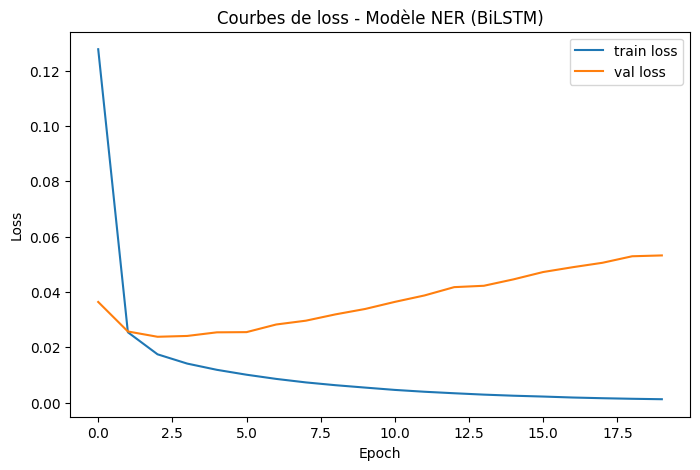

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(ner_history.history["loss"], label="train loss")
plt.plot(ner_history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes de loss - Modèle NER (BiLSTM)")
plt.legend()
plt.show()


## Matrice de confusion (token-level) sur l'ensemble de test

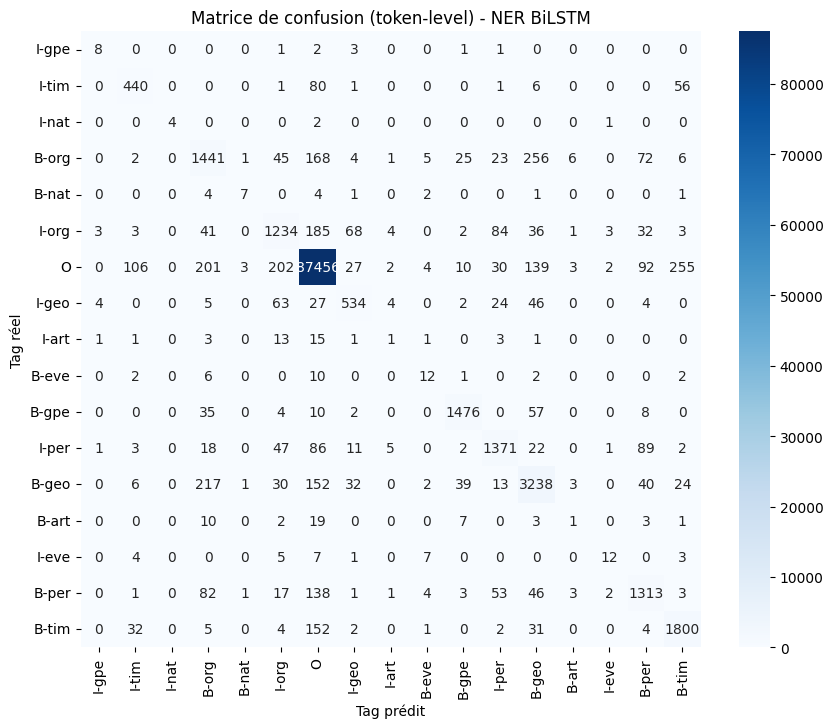

              precision    recall  f1-score   support

       I-gpe       0.47      0.50      0.48        16
       I-tim       0.73      0.75      0.74       585
       I-nat       1.00      0.57      0.73         7
       B-org       0.70      0.70      0.70      2055
       B-nat       0.54      0.35      0.42        20
       I-org       0.74      0.73      0.73      1699
           O       0.99      0.99      0.99     88532
       I-geo       0.78      0.75      0.76       713
       I-art       0.06      0.03      0.03        40
       B-eve       0.32      0.34      0.33        35
       B-gpe       0.94      0.93      0.93      1592
       I-per       0.85      0.83      0.84      1658
       B-geo       0.83      0.85      0.84      3797
       B-art       0.06      0.02      0.03        46
       I-eve       0.57      0.31      0.40        39
       B-per       0.79      0.79      0.79      1668
       B-tim       0.83      0.89      0.86      2033

    accuracy              

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = ner_model.predict(X_test, verbose=0)

y_pred_idx = np.argmax(y_pred, axis=-1).flatten()
y_true_idx = np.argmax(y_test, axis=-1).flatten()

# On exclut le PAD (index 0) pour ne pas fausser la matrice avec le bruit du padding
mask = y_true_idx != 0
y_pred_idx = y_pred_idx[mask]
y_true_idx = y_true_idx[mask]

labels_present = sorted(set(y_true_idx) | set(y_pred_idx))
label_names = [idx2tag[i] for i in labels_present]

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=labels_present)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")
plt.xlabel("Tag prédit")
plt.ylabel("Tag réel")
plt.title("Matrice de confusion (token-level) - NER BiLSTM")
plt.show()

print(classification_report(y_true_idx, y_pred_idx, labels=labels_present, target_names=label_names))


###Pourquoi TimeDistributed(Dense) plutôt qu'un simple Dense ? Rôle de return_sequences=True ?
Pourquoi TimeDistributed(Dense) ?

Dans une tâche de NER, il s'agit d'un problème de classification séquence-à-séquence : chaque token de la phrase doit recevoir son propre tag (O, B-PER, I-LOC, etc.). La sortie de la couche Bidirectional(LSTM(..., return_sequences=True)) est un tenseur de forme (batch_size, max_len, 2*100) : un vecteur caché par pas de temps.

Une couche Dense simple, appliquée directement, ne sait pas nativement traiter une dimension temporelle : elle appliquerait la même transformation en écrasant/ambiguïsant la structure séquentielle. TimeDistributed(Dense(n_tags, activation='softmax')) applique la même couche Dense, avec les mêmes poids, indépendamment à chaque pas de temps de la séquence. On obtient ainsi en sortie un tenseur (batch_size, max_len, n_tags), c'est-à-dire une distribution de probabilité sur les tags pour chaque mot de la phrase, ce qui correspond exactement à ce qu'exige le tagging séquentiel.

Rôle de return_sequences=True dans la BiLSTM :

Par défaut, une couche LSTM ne renvoie que le dernier état caché de la séquence (return_sequences=False), utile pour des tâches de classification globale (ex. Partie A : prédire un seul caractère suivant). Ici, on a besoin d'une prédiction par token, donc il faut que la couche LSTM renvoie l'état caché à chaque pas de temps, d'où return_sequences=True. Combiné à Bidirectional, chaque état caché résulte de la concaténation d'un parcours avant (passé → futur) et d'un parcours arrière (futur → passé), ce qui permet au modèle de prendre en compte le contexte gauche et droit de chaque mot — essentiel en NER, où par exemple reconnaître qu'un mot est un nom de lieu dépend souvent des mots qui le suivent.